In [1]:
from data_utils import *
from import_pkgs import *

In [10]:
CTRL_EM_eff=xr.open_dataset(DATA_PATH+'CTRL_sim_EM_eff.nc')
TEST_EM_eff=xr.open_dataset(DATA_PATH+'TEST_sim_EM_eff.nc')

In [11]:
CTRL_ALB_eff=xr.open_dataset(DATA_PATH+'CTRL_sim_ALB_eff.nc')
TEST_ALB_eff=xr.open_dataset(DATA_PATH+'TEST_sim_ALB_eff.nc')

In [34]:
# larger extent over Asia
ASIA_LAT = (10.0,  60.0)
ASIA_LON = (60.0, 150.0)

DATES_CTRL1 = pd.date_range('2024-02-01', '2024-02-06', freq='D')
DATES_CTRL2 = pd.date_range('2024-02-07', '2024-03-31', freq='D')
DATES_FEB_MAR = pd.date_range('2024-02-01', '2024-03-31', freq='D')

_gub = gpd.read_file(GUB_SHP).to_crs('EPSG:4326')
GUB_UNION = _gub.union_all() if hasattr(_gub, 'union_all') else _gub.unary_union

In [35]:
URBAN_VARS = [
    'EM_eff',
    'ALB_eff',
    'WTLUNIT_ROOF', 'WTROAD_PERV',
    'HT_ROOF', 'CANYON_HWR',
]

LND_VARS = ['TSKIN_U', 'TSA_U', 'RH2M_U']
ATM_VARS = ['PM25', 'O3', 'NO2', 'CO', 'jno2', 'DF_O3', 'DF_CO']

In [36]:
with xr.open_dataset(MUSICA_scrip_path) as _scrip:
    center_lat = _scrip['grid_center_lat'].values.ravel()  
    center_lon = _scrip['grid_center_lon'].values.ravel()   

center_lon[center_lon > 180.0] -= 360.0  

_asia_mask = (
    (center_lat >= ASIA_LAT[0]) & (center_lat <= ASIA_LAT[1]) &
    (center_lon >= ASIA_LON[0]) & (center_lon <= ASIA_LON[1])
)
_asia_idx_bbox = np.where(_asia_mask)[0]

_asia_pts = gpd.GeoSeries(
    [Point(lon, lat)
     for lon, lat in zip(center_lon[_asia_idx_bbox], center_lat[_asia_idx_bbox])],
    crs='EPSG:4326',
)
_gub_mask = _asia_pts.within(GUB_UNION).values
asia_idx  = _asia_idx_bbox[_gub_mask]

asia_lat = center_lat[asia_idx]
asia_lon = center_lon[asia_idx]

print(f"Total MUSICA cells  : {center_lat.size}")
print(f"Asia bbox cells     : {_asia_idx_bbox.size}  (lat {ASIA_LAT}, lon {ASIA_LON})")
print(f"After GUB filter    : {asia_idx.size}")
print(f"Asia cell lat range : {asia_lat.min():.2f} – {asia_lat.max():.2f}")
print(f"Asia cell lon range : {asia_lon.min():.2f} – {asia_lon.max():.2f}")

Total MUSICA cells  : 458111
Asia bbox cells     : 174512  (lat (10.0, 60.0), lon (60.0, 150.0))
After GUB filter    : 1426
Asia cell lat range : 10.24 – 56.52
Asia cell lon range : 62.94 – 141.10


In [37]:
def _file_list(case, component, dates, base=BASE):
    root = Path(f'{base}{case}/')
    ext  = 'cam.h1' if component == 'atm' else 'clm2.h1'
    return [root / f'{component}/hist/{case}.{ext}.{d.strftime("%Y-%m-%d")}-00000.nc'
            for d in dates]


ctrl_atm_files = (_file_list(ctrl_case,      'atm', DATES_CTRL1) +
                  _file_list(ctrl_case_cont, 'atm', DATES_CTRL2))
ctrl_lnd_files = (_file_list(ctrl_case,      'lnd', DATES_CTRL1) +
                  _file_list(ctrl_case_cont, 'lnd', DATES_CTRL2))
test_atm_files = _file_list(test_case, 'atm', DATES_FEB_MAR)
test_lnd_files = _file_list(test_case, 'lnd', DATES_FEB_MAR)

In [38]:
def extract_asia(ds, vname, asia_idx, isel_kw=None):
    da = ds[vname]

    if isel_kw:
        da = da.isel(**{k: v for k, v in isel_kw.items() if k in da.dims})

    spatial_dim = next(
        (dim for dim in da.dims if da.sizes[dim] == 458111), None
    )

    dims_order = [spatial_dim] + [d for d in da.dims if d != spatial_dim]
    data = da.transpose(*dims_order).values 
    return data[asia_idx]   


def build_param_datasets(ctrl_surf_file, test_surf_file, urban_vars, asia_idx):
    ctrl = xr.open_dataset(ctrl_surf_file)
    test = xr.open_dataset(test_surf_file)

    base_sel = {'numurbl': 2}
    alb_sel  = {'numurbl': 2, 'numrad': 0}

    param_datasets = []
    for vname in urban_vars:

        sel={}
        if 'EM' in vname:
            ctrl_vals = extract_asia(CTRL_EM_eff, vname, asia_idx, isel_kw=sel)
            test_vals = extract_asia(TEST_EM_eff, vname, asia_idx, isel_kw=sel)
        elif 'ALB' in vname:
            ctrl_vals = extract_asia(CTRL_ALB_eff, vname, asia_idx, isel_kw=sel)
            test_vals = extract_asia(TEST_ALB_eff, vname, asia_idx, isel_kw=sel)
        else:
            sel = base_sel
            ctrl_vals = extract_asia(ctrl, vname, asia_idx, isel_kw=sel)
            test_vals = extract_asia(test, vname, asia_idx, isel_kw=sel)
        diff = test_vals - ctrl_vals

        finite_frac = np.isfinite(diff).mean() * 100
        print(f"  {vname:22s}  n={diff.size}  "
              f"mean_diff={np.nanmean(diff):+.4f}  finite={finite_frac:.1f}%")
        param_datasets.append(diff)

    ctrl.close()
    test.close()
    return param_datasets


def compute_febmar_mean(file_list, var_list, isel_kw=None):
    ds = xr.open_mfdataset(file_list, combine='by_coords')[var_list]

    if isel_kw:
        ds = ds.isel(**{k: v for k, v in isel_kw.items() if k in ds.dims})

    ds_mean = ds.mean(dim='time')

    sample_da = ds_mean[var_list[0]]
    spatial_dim = next(
        (dim for dim in sample_da.dims if sample_da.sizes[dim] == 458111), None
    )

    result = {}
    for vname in var_list:
        da = ds_mean[vname]
        result[vname] = da.values.ravel()  

    ds.close()
    return result


def build_meteo_aq_deltas(ctrl_lnd_files, test_lnd_files,
                          ctrl_atm_files, test_atm_files,
                          lnd_vars, atm_vars, asia_idx):
    print("\nComputing lnd Feb-Mar means …")
    ctrl_lnd_mean = compute_febmar_mean(ctrl_lnd_files, lnd_vars)
    test_lnd_mean = compute_febmar_mean(test_lnd_files, lnd_vars)

    print("Computing atm Feb-Mar means …")
    ctrl_atm_mean = compute_febmar_mean(ctrl_atm_files, atm_vars, isel_kw={'lev': -1})
    test_atm_mean = compute_febmar_mean(test_atm_files, atm_vars, isel_kw={'lev': -1})

    delta = {}
    print("\nDelta (test - ctrl) over Asia/GUB cells:")
    for vname in lnd_vars + atm_vars:
        src_ctrl = ctrl_lnd_mean if vname in lnd_vars else ctrl_atm_mean
        src_test = test_lnd_mean if vname in lnd_vars else test_atm_mean

        diff_full = src_test[vname] - src_ctrl[vname]   
        diff_asia = diff_full[asia_idx]                 

        finite_frac = np.isfinite(diff_asia).mean() * 100
        print(f"  {vname:8s}  n={diff_asia.size}  "
              f"mean_diff={np.nanmean(diff_asia):+.4f}  finite={finite_frac:.1f}%")
        delta[vname] = diff_asia

    return delta


def build_Xy(y_vec, param_datasets):
    y = np.asarray(y_vec).ravel()
    X = np.column_stack([np.asarray(p).ravel() for p in param_datasets])
    m = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[m], y[m]

def fit_multivar_linear(X, y):
    sx = StandardScaler()
    sy = StandardScaler()
    Xs = sx.fit_transform(X)
    ys = sy.fit_transform(y.reshape(-1, 1)).ravel()
    model = LinearRegression(fit_intercept=True).fit(Xs, ys)
    r2    = r2_score(ys, model.predict(Xs))
    return model.coef_.copy(), r2, Xs, ys

def shapley_r2_linear(X, y, n_perm=3000, random_state=0):
    rng      = np.random.default_rng(random_state)
    n, p     = X.shape
    model    = LinearRegression(fit_intercept=True)
    total_r2 = r2_score(y, model.fit(X, y).predict(X))
    phi      = np.zeros(p, dtype=float)

    for _ in range(n_perm):
        order   = rng.permutation(p)
        used    = []
        prev_r2 = 0.0
        for j in order:
            used.append(j)
            cur_r2  = r2_score(y, model.fit(X[:, used], y).predict(X[:, used]))
            phi[j] += cur_r2 - prev_r2
            prev_r2 = cur_r2

    phi /= float(n_perm)
    if np.isfinite(total_r2) and np.isfinite(phi).all() and phi.sum() != 0:
        phi *= total_r2 / phi.sum()
    return phi, total_r2

def run_regression(y_vec, param_datasets, n_perm=3000, random_state=0):
    X, y = build_Xy(y_vec, param_datasets)
    beta, r2, Xs, ys = fit_multivar_linear(X, y)
    phi, total_r2 = shapley_r2_linear(Xs, ys, n_perm=n_perm,
                                      random_state=random_state)
    return {'beta': beta, 'r2': r2, 'shapley_r2': phi,
            'total_r2': total_r2, 'n': X.shape[0]}

In [39]:
print("\n── Urban surface parameter deltas ──")
param_datasets = build_param_datasets(CTRL_SURF, TEST_SURF, URBAN_VARS, asia_idx)

print(f"\nparam_datasets ready: {len(param_datasets)} arrays, "
      f"each length {param_datasets[0].size}")


── Urban surface parameter deltas ──
  EM_eff                  n=1426  mean_diff=+0.0086  finite=94.6%
  ALB_eff                 n=1426  mean_diff=-0.0659  finite=94.6%
  WTLUNIT_ROOF            n=1426  mean_diff=-0.1698  finite=100.0%
  WTROAD_PERV             n=1426  mean_diff=-0.2691  finite=100.0%
  HT_ROOF                 n=1426  mean_diff=+0.0865  finite=100.0%
  CANYON_HWR              n=1426  mean_diff=-0.0053  finite=100.0%

param_datasets ready: 6 arrays, each length 1426


In [40]:
print("\n── Meteo and AQ deltas ──")
meteo_aq_delta = build_meteo_aq_deltas(
    ctrl_lnd_files, test_lnd_files,
    ctrl_atm_files, test_atm_files,
    LND_VARS, ATM_VARS, asia_idx,
)


── Meteo and AQ deltas ──

Computing lnd Feb-Mar means …


/glade/derecho/scratch/yifanc17/tmp/ipykernel_30838/3408309006.py:67: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_list, combine='by_coords')[var_list]
/glade/derecho/scratch/yifanc17/tmp/ipykernel_30838/3408309006.py:67: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mf

Computing atm Feb-Mar means …


/glade/derecho/scratch/yifanc17/tmp/ipykernel_30838/3408309006.py:67: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_list, combine='by_coords')[var_list]
/glade/derecho/scratch/yifanc17/tmp/ipykernel_30838/3408309006.py:67: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mf


Delta (test - ctrl) over Asia/GUB cells:
  TSKIN_U   n=1426  mean_diff=+0.2134  finite=94.6%
  TSA_U     n=1426  mean_diff=+0.1303  finite=94.6%
  RH2M_U    n=1426  mean_diff=+0.1065  finite=94.6%
  PM25      n=1426  mean_diff=-0.0000  finite=100.0%
  O3        n=1426  mean_diff=+0.0000  finite=100.0%
  NO2       n=1426  mean_diff=-0.0000  finite=100.0%
  CO        n=1426  mean_diff=+0.0000  finite=100.0%
  jno2      n=1426  mean_diff=-0.0000  finite=100.0%
  DF_O3     n=1426  mean_diff=+0.0000  finite=100.0%
  DF_CO     n=1426  mean_diff=-0.0000  finite=100.0%


In [41]:
RESPONSE_VARS = LND_VARS + ATM_VARS  

response_desc = [
    'Land surface T', '2m T', '2m RH',
    'PM$_{2.5}$', 'O$_3$', 'NO$_2$', 'CO', 'jno2', 'DF$_{O3}$' ,'DF$_{CO}$',
]
row_names = [rf'$\Delta$ {v}' for v in response_desc]

var_desc = [
    'Eff $e$',  
    'Eff $\\alpha$',  
    'Roof frac',          'Pervious frac',
    'Roof $H$',           'Canyon $H/W$',
]
xticklabels = [rf'$\Delta$ {v}' for v in var_desc]

BETA_list, PHI_list, R2_list, N_list = [], [], [], []

for k, vname in enumerate(RESPONSE_VARS):
    print(f"Fitting {vname} ({k+1}/{len(RESPONSE_VARS)}) …")
    out = run_regression(meteo_aq_delta[vname], param_datasets,
                         n_perm=3000, random_state=42 + k)
    BETA_list.append(out['beta'])
    PHI_list.append(out['shapley_r2'])
    R2_list.append(out['total_r2'])
    N_list.append(out['n'])

BETA     = np.asarray(BETA_list)    
PHI      = np.asarray(PHI_list)     
R2_total = np.asarray(R2_list)     
N_eff    = np.asarray(N_list)      

np.save('BETA_asia_meteoAQ_febmar_effective_EM_ALB_jno2_DF_Asia_bbox.npy',  BETA)
np.save('PHI_asia_meteoAQ_febmar_effective_EM_ALB_jno2_DF_Asia_bbox.npy',   PHI)
np.save('R2_asia_meteoAQ_febmar_effective_EM_ALB_jno2_DF_Asia_bbox.npy',    R2_total)
np.save('N_eff_asia_meteoAQ_febmar_effective_EM_ALB_jno2_DF_Asia_bbox.npy', N_eff)

Fitting TSKIN_U (1/10) …
Fitting TSA_U (2/10) …
Fitting RH2M_U (3/10) …
Fitting PM25 (4/10) …
Fitting O3 (5/10) …
Fitting NO2 (6/10) …
Fitting CO (7/10) …
Fitting jno2 (8/10) …
Fitting DF_O3 (9/10) …
Fitting DF_CO (10/10) …


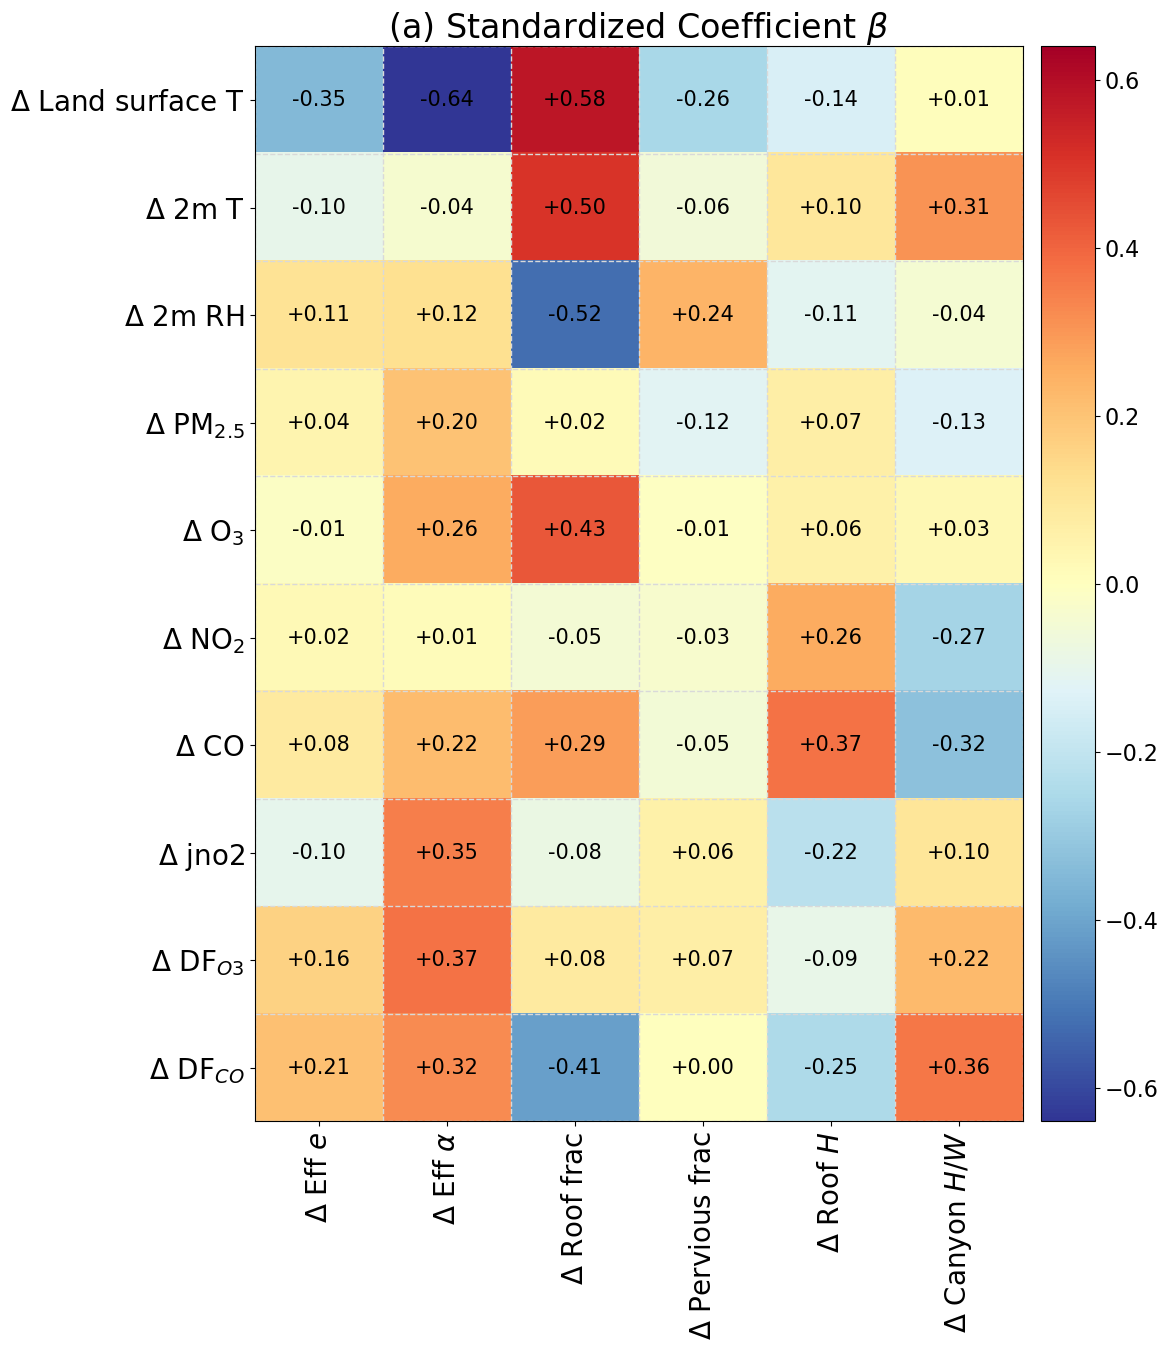

In [43]:
nrow, ncol = BETA.shape
vmax = np.nanmax(np.abs(BETA))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

figA, axA = plt.subplots(figsize=(12, 1.2 * nrow + 1.6))
imA = axA.imshow(
    BETA, aspect='auto', cmap='RdYlBu_r',
    norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
)
for i in range(nrow):
    for j in range(ncol):
        val = BETA[i, j]
        if np.isfinite(val):
            axA.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=15)

axA.set_xlim(-0.5, ncol - 0.5)
axA.set_ylim(nrow - 0.5, -0.5)
axA.set_yticks(np.arange(nrow));       axA.set_yticklabels(row_names, fontsize=20)
axA.set_xticks(np.arange(ncol));       axA.set_xticklabels(xticklabels, rotation=90, fontsize=20)
axA.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
axA.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
axA.grid(which='minor', color='0.85', linewidth=1, linestyle='--')
axA.tick_params(which='minor', bottom=False, left=False)
figA.colorbar(imA, ax=axA, pad=0.02).ax.tick_params(labelsize=16)
axA.set_title('(a) Standardized Coefficient $\\beta$', fontsize=24)
plt.tight_layout()
plt.show()

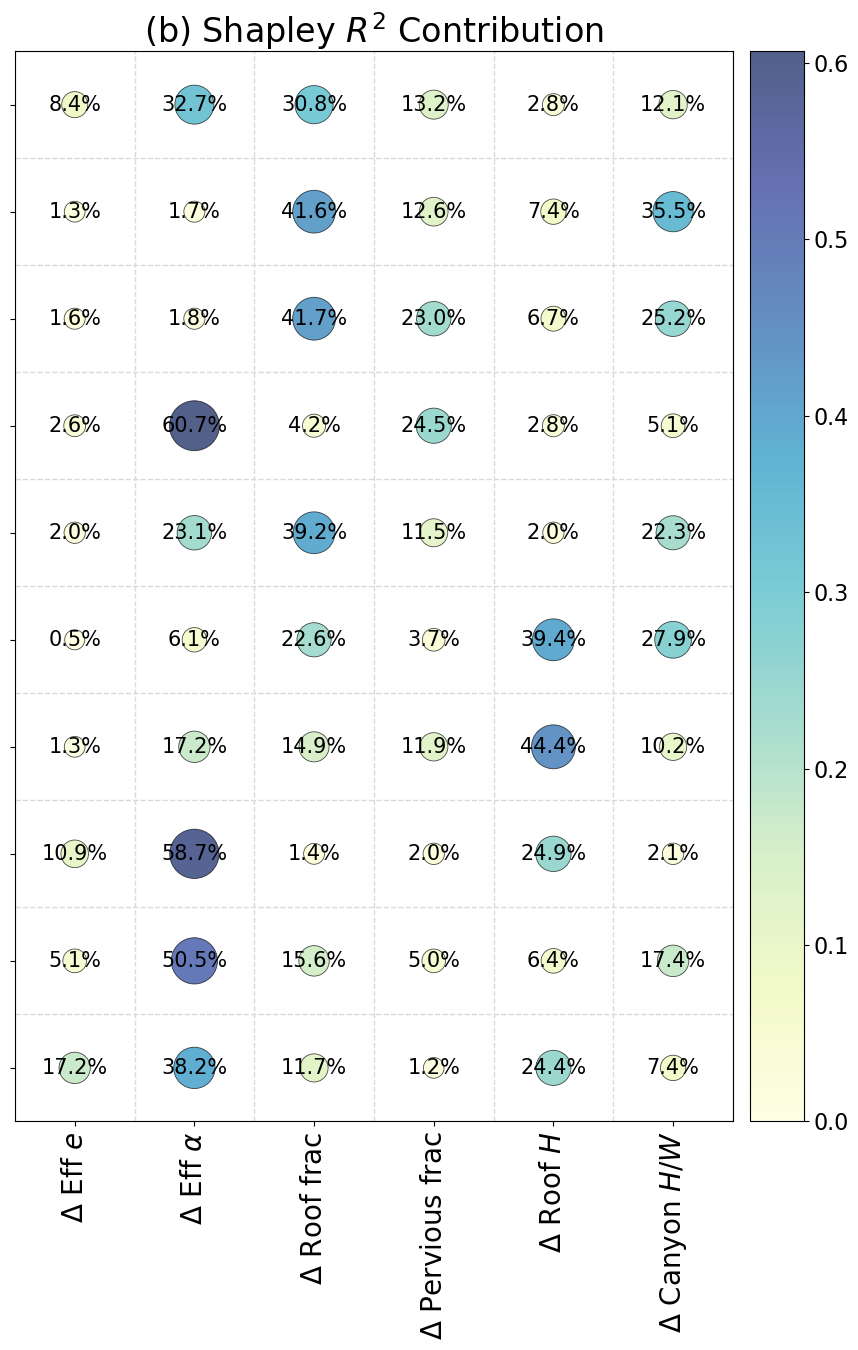

In [44]:
PHI_frac = np.full_like(PHI, np.nan)
m_pos = np.isfinite(R2_total) & (R2_total > 0)
PHI_frac[m_pos] = PHI[m_pos] / R2_total[m_pos, None]

figB, axB = plt.subplots(figsize=(9, 1.2 * nrow + 1.6))
xx, yy   = np.meshgrid(np.arange(ncol), np.arange(nrow))
smin, smax = 200, 2000
S       = smin + (smax - smin) * np.nan_to_num(PHI_frac, nan=0.0)
phi_max = np.nanmax(PHI_frac) if np.isfinite(np.nanmax(PHI_frac)) else 1.0

scB = axB.scatter(
    xx.ravel(), yy.ravel(),
    s=S.ravel(), c=PHI_frac.ravel(),
    cmap='YlGnBu', vmin=0.0, vmax=phi_max,
    edgecolors='k', linewidths=0.6, alpha=0.7,
)
for i in range(nrow):
    for j in range(ncol):
        val = PHI_frac[i, j]
        if np.isfinite(val):
            axB.text(j, i, f'{100*val:.1f}%', ha='center', va='center', fontsize=15)

axB.set_xlim(-0.5, ncol - 0.5)
axB.set_ylim(nrow - 0.5, -0.5)
axB.set_yticks(np.arange(nrow));       axB.set_yticklabels([], fontsize=16)
axB.set_xticks(np.arange(ncol));       axB.set_xticklabels(xticklabels, rotation=90, fontsize=20)
axB.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
axB.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
axB.grid(which='minor', color='0.85', linewidth=1, linestyle='--')
axB.tick_params(which='minor', bottom=False, left=False)
figB.colorbar(scB, ax=axB, pad=0.02).ax.tick_params(labelsize=16)
axB.set_title(r'(b) Shapley $R^2$ Contribution', fontsize=24)
plt.tight_layout()
plt.show()

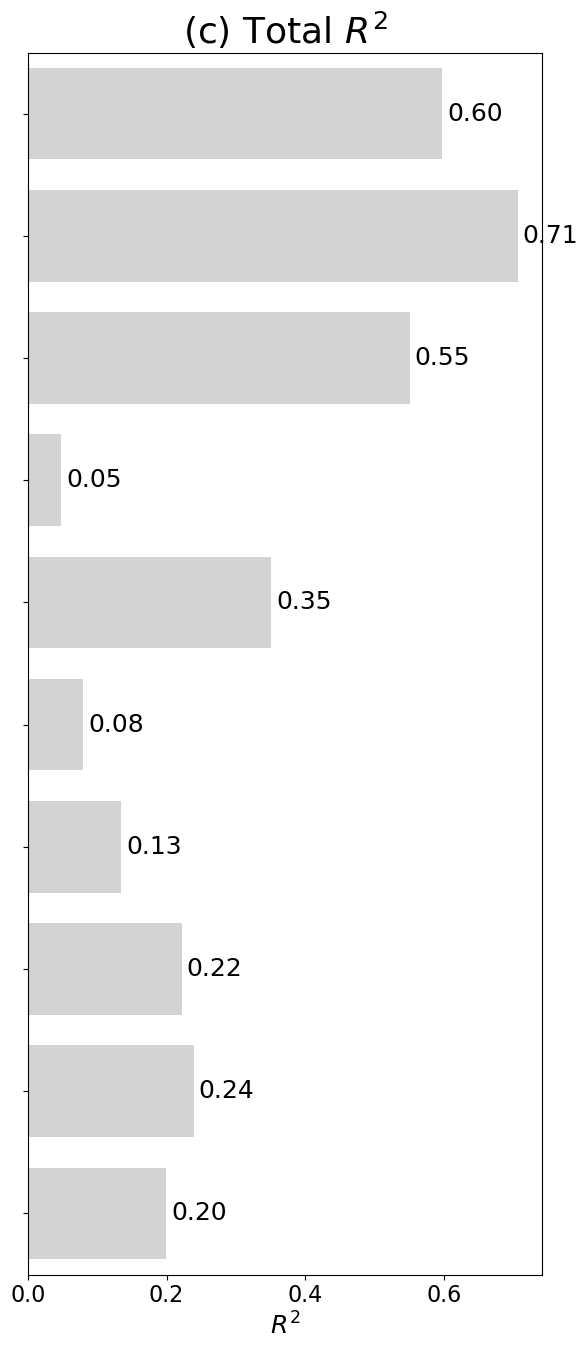

In [45]:
figC, axC = plt.subplots(figsize=(6, 1.2 * nrow + 1.6))
ypos = np.arange(nrow)
axC.barh(ypos, R2_total, height=0.75, color='lightgray')
axC.set_ylim(nrow - 0.5, -0.5)
axC.set_yticks(np.arange(nrow));  axC.set_yticklabels([], fontsize=16)
axC.set_xlabel(r'$R^2$', fontsize=18)
axC.tick_params(axis='x', labelsize=16)
r2max = np.nanmax(R2_total) if np.isfinite(np.nanmax(R2_total)) else 1.0
pad   = 0.01 * r2max
for i in range(nrow):
    r2 = R2_total[i]
    if np.isfinite(r2):
        axC.text(r2 + pad, i, f'{r2:.2f}', va='center', fontsize=18)
axC.set_title(r'(c) Total $R^2$', fontsize=26)
plt.tight_layout()
plt.show()